# MLP Project - Comment Category Prediction

## Objective
The goal of this project is to predict the correct **label** of a comment using:
- comment text
- categorical features
- numeric features
- time-based features

This is a **multi-class classification problem**.

## Workflow
In this notebook, I will:
1. Load and understand the dataset
2. Perform basic EDA
3. Preprocess text and other features
4. Create text, numeric, and categorical features
5. Train **3 models**
6. Compare the models
7. Select the best model
8. Generate final submission

## Final Aim
The purpose of this notebook is not only to train models, but also to **compare multiple approaches and choose the best one** for final prediction.

In [1]:
# Importing  libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from lightgbm import LGBMClassifier, early_stopping, log_evaluation



# 1. Load Dataset

In this step, I load the competition files.

- `train.csv` contains features and target label
- `test.csv` contains features only
- `sample_submission.csv` shows the required output format

In [2]:
# Load datasets
train_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sample_df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

# Check shapes
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample shape:", sample_df.shape)

# Preview training data
train_df.head()

Train shape: (198000, 15)
Test shape: (102000, 14)
Sample shape: (102000, 2)


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


# 2. Basic Inspection

Before training any model, it is important to understand:
- column names
- missing values
- data types
- target column

In [3]:
# Check column names
print("Columns in train dataset:\n")
print(train_df.columns.tolist())

# Check missing values
print("\nMissing values in train:\n")
print(train_df.isnull().sum())

print("\nMissing values in test:\n")
print(test_df.isnull().sum())

# Check data types
print("\nData types:\n")
print(train_df.dtypes)

Columns in train dataset:

['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment', 'label']

Missing values in train:

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

Missing values in test:

created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64

Data types:

created_date    object
post_id          int64
emoticon_

# 3. Define Features

From the notebook, the main columns used are:

## Text Feature
- `comment`

## Categorical Features
- `race`
- `religion`
- `gender`

## Numeric Features
- `emoticon_1`
- `emoticon_2`
- `emoticon_3`
- `upvote`
- `downvote`
- `if_1`
- `if_2`
- `disability`

## Date Feature
- `created_date`

## Target
- `label`

In [4]:
# Define column groups
text_col = "comment"
cat_cols = ["race", "religion", "gender"]
num_cols = ["emoticon_1", "emoticon_2", "emoticon_3", "upvote", "downvote", "if_1", "if_2", "disability"]
date_col = "created_date"
target_col = "label"

# Print column info
print("Target column:", target_col)
print("Text column:", text_col)
print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

Target column: label
Text column: comment
Categorical columns: ['race', 'religion', 'gender']
Numeric columns: ['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'disability']


# 4. Target Distribution

Now I check how the target labels are distributed.

This is useful because if some classes are much bigger than others, the model can become biased.

Number of classes: 4
label
0    114173
1     15918
2     62440
3      5469
Name: count, dtype: int64


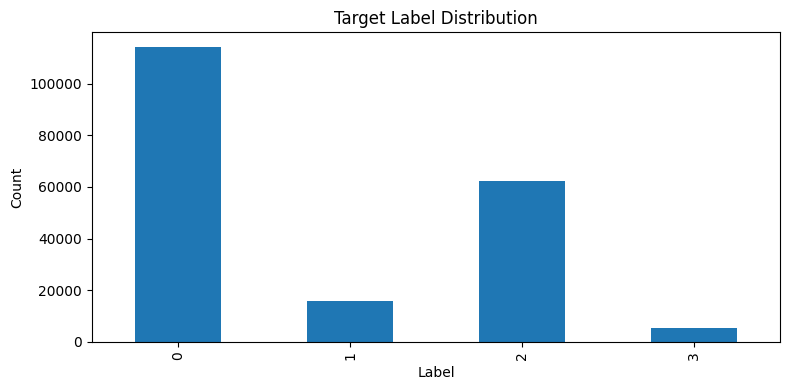

In [5]:
# Count target labels
label_counts = train_df[target_col].value_counts().sort_index()

# Print basic info
print("Number of classes:", train_df[target_col].nunique())
print(label_counts)

# Plot distribution
plt.figure(figsize=(8, 4))
label_counts.plot(kind="bar")
plt.title("Target Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 5. Data Preprocessing

In this step, I clean the data so that it can be used by machine learning models.

Main preprocessing steps:
- fill missing text values
- fill missing categorical values
- fill missing numeric values
- process date column
- create time-based features

In [6]:
# Create copies of data
train = train_df.copy()
test = test_df.copy()

# Fill missing text
train[text_col] = train[text_col].fillna("missing_text").astype(str)
test[text_col] = test[text_col].fillna("missing_text").astype(str)

# Fill categorical columns
for col in cat_cols:
    train[col] = train[col].fillna("None").astype(str)
    test[col] = test[col].fillna("None").astype(str)

# Fill numeric columns
for col in num_cols:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)

# Convert disability to int
train["disability"] = train["disability"].astype(int)
test["disability"] = test["disability"].astype(int)

# Process date features
train[date_col] = pd.to_datetime(train[date_col], errors="coerce")
test[date_col] = pd.to_datetime(test[date_col], errors="coerce")

train["hour"] = train[date_col].dt.hour.fillna(0).astype(int)
train["day_of_week"] = train[date_col].dt.dayofweek.fillna(0).astype(int)

test["hour"] = test[date_col].dt.hour.fillna(0).astype(int)
test["day_of_week"] = test[date_col].dt.dayofweek.fillna(0).astype(int)

# Add comment length feature
train["comment_length"] = train[text_col].apply(len)
test["comment_length"] = test[text_col].apply(len)

print("Preprocessing completed.")

Preprocessing completed.


# 6. EDA - Comment Length Distribution

Comment length is an important text feature.

Some comments may be very short, while some may be long.  
This can affect model performance and helps us understand the nature of the dataset.

count    198000.000000
mean        302.909424
std         266.441682
min           1.000000
25%         102.000000
50%         211.000000
75%         419.000000
max        1892.000000
Name: comment_length, dtype: float64


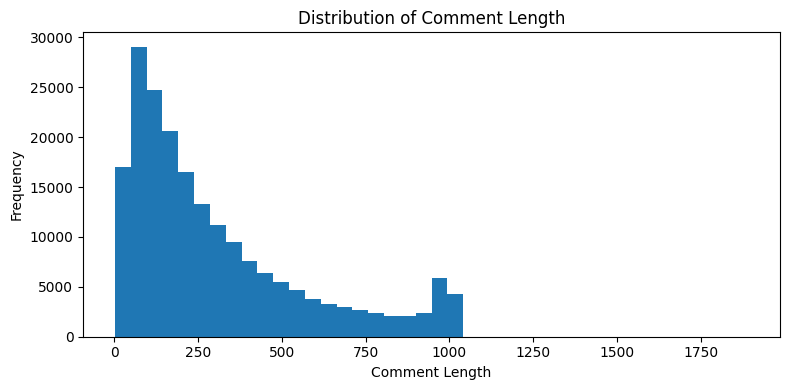

In [7]:
# Summary of comment length
print(train["comment_length"].describe())

# Plot distribution
plt.figure(figsize=(8, 4))
plt.hist(train["comment_length"], bins=40)
plt.title("Distribution of Comment Length")
plt.xlabel("Comment Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 7. EDA - Numeric Feature Summary

Now I inspect the numeric features used in the notebook.

These features give extra information apart from the raw text.

In [8]:
# Combine numeric features
eda_num_cols = num_cols + ["hour", "day_of_week", "comment_length"]

# Show summary statistics
train[eda_num_cols].describe()

,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,disability,hour,day_of_week,comment_length
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.013854,12.128833,3.069354,302.909424
std,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.116883,8.082283,2.059938,266.441682
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000,4.000000,1.000000,102.000000
50%,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000,13.000000,3.000000,211.000000
75%,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,0.000000,20.000000,5.000000,419.000000
max,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,1.000000,23.000000,6.000000,1892.000000


# 8. EDA - Average Comment Length by Label

This graph shows whether some classes tend to have longer or shorter comments.

This is useful because text size itself may carry some pattern.

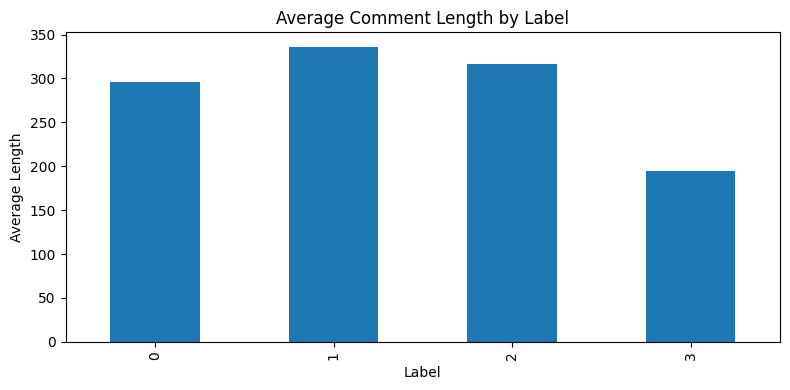

In [9]:
# Average comment length per label
avg_len_by_label = train.groupby(target_col)["comment_length"].mean().sort_index()

# Plot results
plt.figure(figsize=(8, 4))
avg_len_by_label.plot(kind="bar")
plt.title("Average Comment Length by Label")
plt.xlabel("Label")
plt.ylabel("Average Length")
plt.tight_layout()
plt.show()

# 9. Encode Categorical Features

The categorical features cannot be directly used in ML models.

So I convert them into numeric form using **one-hot encoding**.

In [10]:
# One-hot encode categorical features
train_cat = pd.get_dummies(train[cat_cols], columns=cat_cols, dummy_na=False)
test_cat = pd.get_dummies(test[cat_cols], columns=cat_cols, dummy_na=False)

# Align train and test columns
train_cat, test_cat = train_cat.align(test_cat, join='left', axis=1, fill_value=0)

# Check shapes
print("Train categorical encoded shape:", train_cat.shape)
print("Test categorical encoded shape:", test_cat.shape)

Train categorical encoded shape: (198000, 22)
Test categorical encoded shape: (102000, 22)


# 10. Prepare Numeric Features

Now I prepare all final numeric features.

These include:
- emoticon counts
- upvotes and downvotes
- indicator variables
- disability
- hour
- day of week
- comment length

In [11]:
# Final numeric features
final_num_cols = num_cols + ["hour", "day_of_week", "comment_length"]

# Convert numeric features to sparse matrix
X_num_train = csr_matrix(train[final_num_cols].values)
X_num_test = csr_matrix(test[final_num_cols].values)

# Convert categorical features to sparse matrix
X_cat_train = csr_matrix(train_cat.values)
X_cat_test = csr_matrix(test_cat.values)

# Check shapes
print("Numeric feature shape:", X_num_train.shape)
print("Categorical feature shape:", X_cat_train.shape)

Numeric feature shape: (198000, 11)
Categorical feature shape: (198000, 22)


# 11. Word-Level TF-IDF

I use word-level TF-IDF to convert text into numeric form.

## Why word TF-IDF?
It captures:
- important words
- useful word pairs
- word importance across documents

In [12]:
# TF-IDF for text features
word_vectorizer = TfidfVectorizer(
    max_features=20000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True
)

# Fit on train and transform both
X_word_train = word_vectorizer.fit_transform(train[text_col])
X_word_test = word_vectorizer.transform(test[text_col])

# Check shapes
print("Word TF-IDF train shape:", X_word_train.shape)
print("Word TF-IDF test shape:", X_word_test.shape)

Word TF-IDF train shape: (198000, 20000)
Word TF-IDF test shape: (102000, 20000)


# 12. Character-Level TF-IDF

I also use character-level TF-IDF.

## Why character TF-IDF?
It helps capture:
- spelling variation
- repeated letters
- short noisy patterns
- modified abusive words

This is useful for real-world comment text.

In [13]:
# Character-level TF-IDF
char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=3,
    max_features=25000,
    sublinear_tf=True
)

# Fit on train and transform both
X_char_train = char_vectorizer.fit_transform(train[text_col])
X_char_test = char_vectorizer.transform(test[text_col])

# Check shapes
print("Character TF-IDF train shape:", X_char_train.shape)
print("Character TF-IDF test shape:", X_char_test.shape)

Character TF-IDF train shape: (198000, 25000)
Character TF-IDF test shape: (102000, 25000)


# 13. Final Feature Matrix

Now I combine all features into one final matrix:

- word TF-IDF
- character TF-IDF
- numeric features
- categorical encoded features

This gives the model both text and metadata information.

In [14]:
# Combine all features
X_full_train = hstack([X_word_train, X_char_train, X_num_train, X_cat_train]).tocsr()
X_full_test = hstack([X_word_test, X_char_test, X_num_test, X_cat_test]).tocsr()

# Target variable
y = train[target_col]

# Check final shapes
print("Final train matrix shape:", X_full_train.shape)
print("Final test matrix shape:", X_full_test.shape)

Final train matrix shape: (198000, 45033)
Final test matrix shape: (102000, 45033)


# 14. Train Validation Split

I split the training data into:
- 85% training
- 15% validation

I use stratified splitting so that the class distribution remains similar in both sets.

In [15]:
# Split data into train and validation
X_tr, X_val, y_tr, y_val = train_test_split(
    X_full_train,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# Check shapes
print("Training shape:", X_tr.shape)
print("Validation shape:", X_val.shape)

Training shape: (168300, 45033)
Validation shape: (29700, 45033)


# 15. Model 1 - Multinomial Naive Bayes

This is a simple and strong baseline for text classification.

## Why use it?
- fast to train
- works well with sparse text features
- good baseline for comparison

In [16]:
# Train Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_tr, y_tr)

# Predict on validation data
nb_val_pred = nb_model.predict(X_val)

# Calculate accuracy
nb_acc = accuracy_score(y_val, nb_val_pred)

print("MultinomialNB Validation Accuracy:", nb_acc)

MultinomialNB Validation Accuracy: 0.5192929292929293


# 16. Model 2 - Linear SVC

Linear SVC is a fast and effective model for text classification.

## Why use it?
- fast to train
- works well with TF-IDF features
- strong baseline for text data
- good for comparison with other models

In [17]:
# Train Linear SVC model
svm_model = LinearSVC()
svm_model.fit(X_tr, y_tr)

# Predict on validation data
svm_val_pred = svm_model.predict(X_val)

# Calculate accuracy
svm_acc = accuracy_score(y_val, svm_val_pred)

print("LinearSVC Validation Accuracy:", svm_acc)

LinearSVC Validation Accuracy: 0.8012121212121213


# 17. Model 3 - LightGBM

LightGBM is used here as the advanced model.

## Why use it?
- efficient and fast
- good for large feature spaces
- supports tuning and early stopping
- can learn more complex patterns

In [18]:
# Number of classes
num_classes = y.nunique()

# Train LightGBM model
lgbm_model = LGBMClassifier(
    objective="multiclass",
    num_class=num_classes,
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42
)

lgbm_model.fit(
    X_tr,
    y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric="multi_logloss",
    callbacks=[
        early_stopping(stopping_rounds=80),
        log_evaluation(period=100)
    ]
)

# Predict and evaluate
lgbm_val_pred = lgbm_model.predict(X_val)
lgbm_acc = accuracy_score(y_val, lgbm_val_pred)

print("LightGBM Validation Accuracy:", lgbm_acc)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 125.448658 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7275666
[LightGBM] [Info] Number of data points in the train set: 168300, number of used features: 44955
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Training until validation scores don't improve for 80 rounds
[100]	valid_0's multi_logloss: 0.317783
[200]	valid_0's multi_logloss: 0.28305
[300]	valid_0's multi_logloss: 0.269418
[400]	valid_0's multi_logloss: 0.262642
[500]	valid_0's multi_logloss: 0.259319
[600]	valid_0's multi_logloss: 0.25903
Early stopping, best iteration is:
[554]	valid_0's multi_logloss: 0.25879
LightGBM Validation Accuracy: 0.9173063973063973


# 19. Model Comparison

Now I compare the 3 models on validation accuracy.

This helps in selecting the best model instead of choosing a model without evidence.

In [19]:
# Create comparison table
results_df = pd.DataFrame({
    "Model": ["MultinomialNB", "LinearSVC", "LightGBM"],
    "Validation Accuracy": [nb_acc, svm_acc, lgbm_acc]
}).sort_values(by="Validation Accuracy", ascending=False).reset_index(drop=True)

# Show results
results_df

,Model,Validation Accuracy
0,LightGBM,0.917306
1,LinearSVC,0.801212
2,MultinomialNB,0.519293


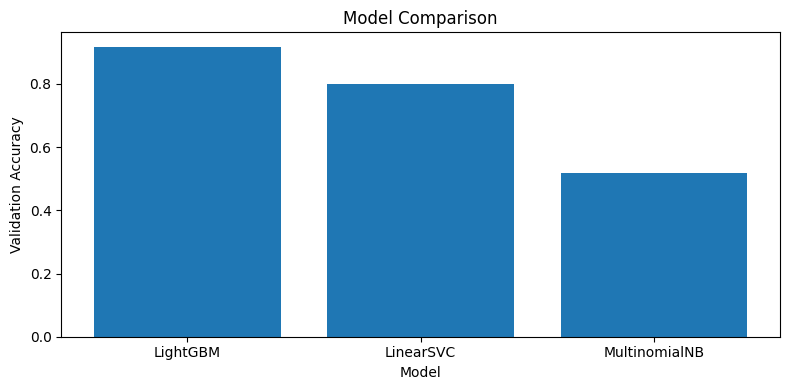

In [20]:
# Plot comparison
plt.figure(figsize=(8, 4))
plt.bar(results_df["Model"], results_df["Validation Accuracy"])
plt.title("Model Comparison")
plt.xlabel("Model")
plt.ylabel("Validation Accuracy")
plt.tight_layout()
plt.show()

# 19. Best Model Selection

From the comparison table, I select the model with the best validation accuracy.

This is the final model used for test prediction and submission.

In [21]:
# Get best model from results
best_model_name = results_df.loc[0, "Model"]
best_model_score = results_df.loc[0, "Validation Accuracy"]

# Print best model info
print("Best Model:", best_model_name)
print("Best Validation Accuracy:", best_model_score)

Best Model: LightGBM
Best Validation Accuracy: 0.9173063973063973


# 20. Why I Selected the Best Model

The final model is selected based on validation performance.

This is important because:
- different models behave differently on text data
- a model should be selected based on result, not only on assumption
- comparison makes the notebook stronger and more complete

In [22]:
# Select best model based on result
if best_model_name == "MultinomialNB":
    best_model = nb_model
elif best_model_name == "LinearSVC":
    best_model = svm_model
else:
    best_model = lgbm_model

print("Selected final model:", best_model)

Selected final model: LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
               learning_rate=0.05, n_estimators=2000, num_class=4,
               num_leaves=64, objective='multiclass', random_state=42,
               subsample=0.8)


In [23]:
# Evaluate best model
best_val_pred = best_model.predict(X_val)

print(classification_report(y_val, best_val_pred))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     17126
           1       0.73      0.85      0.79      2388
           2       0.88      0.90      0.89      9366
           3       0.66      0.72      0.69       820

    accuracy                           0.92     29700
   macro avg       0.81      0.86      0.83     29700
weighted avg       0.92      0.92      0.92     29700



# 21. Final Test Prediction

Now I use the best selected model to generate predictions on the test data.

In [24]:
# Generate predictions on test data
if best_model_name == "LightGBM":
    test_proba = best_model.predict_proba(X_full_test)
    test_proba = np.power(test_proba, 1.1)
    test_proba = test_proba / test_proba.sum(axis=1, keepdims=True)
    test_pred = np.argmax(test_proba, axis=1)
else:
    test_pred = best_model.predict(X_full_test)

print("Test prediction completed.")
print(test_pred[:10])

Test prediction completed.
[2 2 0 0 2 0 1 0 0 2]


# 22. Final Submission


In [25]:
# Create submission file
submission = sample_df.copy()
submission[target_col] = test_pred
submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully.")
submission.head()

submission.csv created successfully.


,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2
